In [1]:
import pandas as pd
from src.data_loader import data_loader

houses_raw = data_loader()

First I need to split set for test and train sets.

In [8]:
houses_raw['OverallQual'].describe()

count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

In [9]:
import numpy as np

houses_raw["QualCat"] = pd.cut(houses_raw["OverallQual"],
                               bins=[0, 2, 4, 6, 8, 10],
                               labels=[1, 2, 3,4, 5])

<Axes: xlabel='QualCat'>

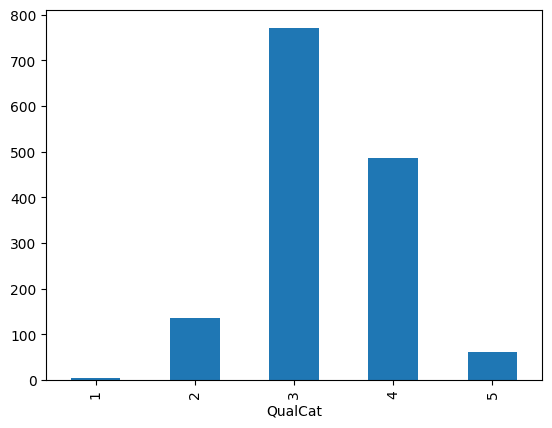

In [10]:
houses_raw['QualCat'].value_counts().sort_index(ascending=True).plot(kind='bar')

In [13]:
houses_raw['QualCat'].value_counts().sort_index()

QualCat
1      5
2    136
3    771
4    487
5     61
Name: count, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(houses_raw, stratify=houses_raw['QualCat'], test_size=0.2, random_state=42)

After spliting data we have to delete 'QualCat' from our train and test sets.

In [16]:
for set_ in train_set, test_set:
    set_.drop('QualCat', axis=1, inplace=True)

In [ ]:
houses_raw.head(10)

We can add some features which might be helpful and make our data more descriptive.

In [ ]:
houses_added_features = houses_raw.copy()
houses_added_features.head()

In [ ]:
#Total area of the house
houses_added_features["TotalSF"] = houses_added_features["TotalBsmtSF"] + houses_added_features["1stFlrSF"] + houses_added_features["2ndFlrSF"]

#House age
houses_added_features["HouseAge"] = houses_added_features["YrSold"] - houses_added_features["YearBuilt"]
houses_added_features["RemodelAge"] = houses_added_features["YrSold"] - houses_added_features["YearRemodAdd"]
houses_added_features["WasRemodeled"] = (houses_added_features["YearBuilt"] != houses_added_features["YearRemodAdd"]).astype(int)

#łazienki
houses_added_features["TotalBath"] = (houses_added_features["FullBath"] +
                                       houses_added_features["HalfBath"] * 0.5 +
                                       houses_added_features["BsmtFullBath"] +
                                       houses_added_features["BsmtHalfBath"] * 0.5)

#garaż
houses_added_features["GarageAreaPerCar"] = houses_added_features["GarageArea"] / (houses_added_features["GarageCars"] + 1)

#udogodnienia
houses_added_features["HasPool"] = (houses_added_features["PoolArea"] > 0).astype(int)
houses_added_features["HasBasement"] = (houses_added_features["TotalBsmtSF"] > 0).astype(int)
houses_added_features["HasGarage"] = (houses_added_features["GarageArea"] > 0).astype(int)
houses_added_features["HasFireplace"] = (houses_added_features["Fireplaces"] > 0).astype(int)

#jakość nieruchomości
houses_added_features["QualXSF"] = houses_added_features["OverallQual"] * houses_added_features["GrLivArea"]

In [ ]:
houses_added_features[["TotalSF","HouseAge","RemodelAge","WasRemodeled","TotalBath","GarageAreaPerCar","HasPool","HasBasement","HasGarage","HasFireplace","QualXSF"]]

In [ ]:
import seaborn as sns

corr_matrix = houses_added_features.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
sns.barplot(x = corr_matrix.values[:10], y = houses_added_features.columns[:10])


None from added features are valuable for our model.